Preparação do ambiente

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Análise exploratória

In [2]:
df = pd.read_csv('winequality-red (1).csv', sep=';')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
#Analise exploratoria
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


# Correlação

In [5]:
df_principal = df[['alcohol','sulphates','volatile acidity','quality']]
df_principal.corr()


,alcohol,sulphates,volatile acidity,quality
alcohol,1.000000,0.093595,-0.202288,0.476166
sulphates,0.093595,1.000000,-0.260987,0.251397
volatile acidity,-0.202288,-0.260987,1.000000,-0.390558
quality,0.476166,0.251397,-0.390558,1.000000


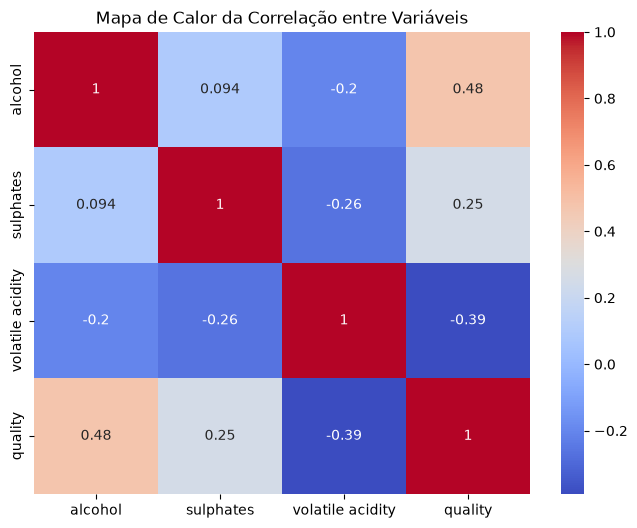

In [6]:
import seaborn as sns
matriz_de_correlacao = df_principal.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_de_correlacao, annot=True, cmap='coolwarm')
plt.title('Mapa de Calor da Correlação entre Variáveis')
plt.show()

# Gráficos de dispersão

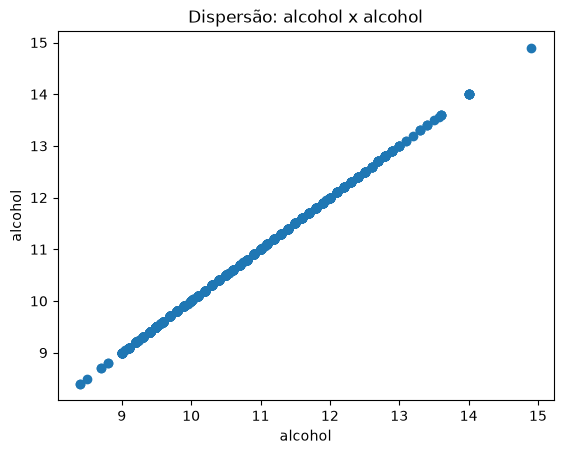

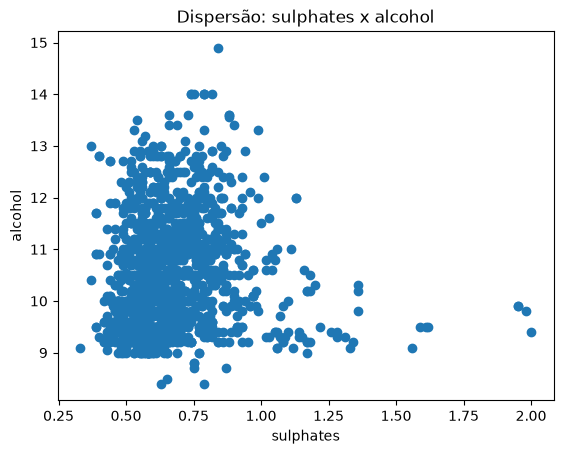

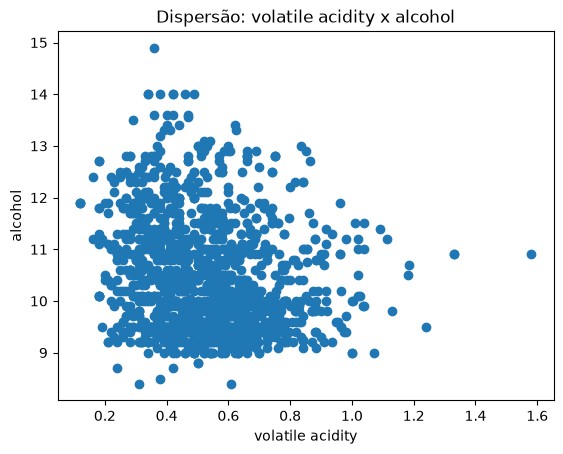

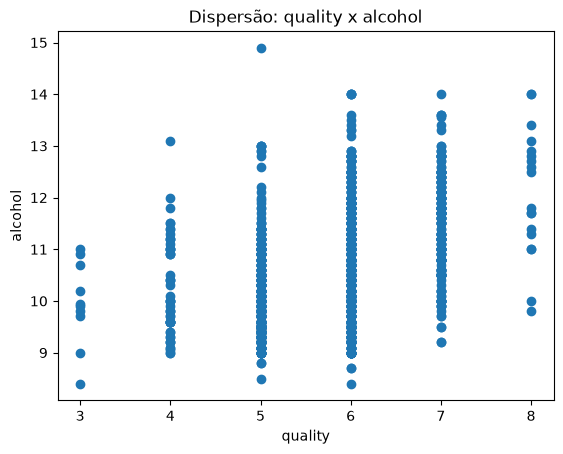

In [7]:
for col in df_principal.columns:
    plt.figure()
    plt.scatter(df_principal[col], df_principal['alcohol'])
    plt.xlabel(col)
    plt.ylabel('alcohol')
    plt.title(f'Dispersão: {col} x alcohol')
    plt.show()

Podemos observar que parte dessas variáveis aparenta ter uma correlação linear,
o que **não garante**, mas **sugere** que a regressão linear múltipla é um caminho razoável.
Lembre-se: linearidade aproximada é uma **condição desejável** para a regressão linear.

# Identificando e Removendo *outliers*

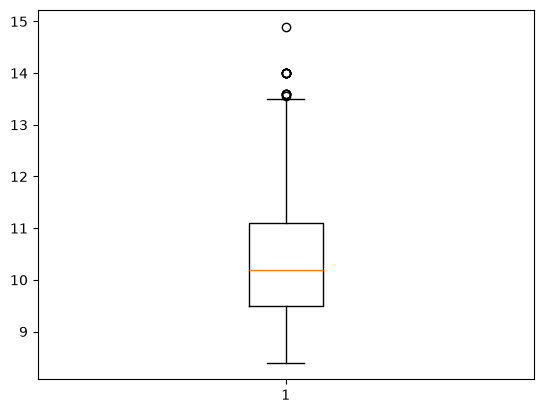

In [8]:
plt.boxplot(df_principal['alcohol'])
plt.show()

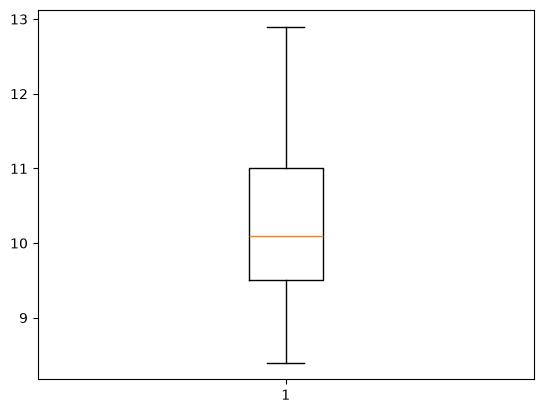

In [9]:
df_principal = df_principal[(df_principal['alcohol']<13) & (df_principal['alcohol']>5)]
plt.boxplot(df_principal['alcohol'])
plt.show()

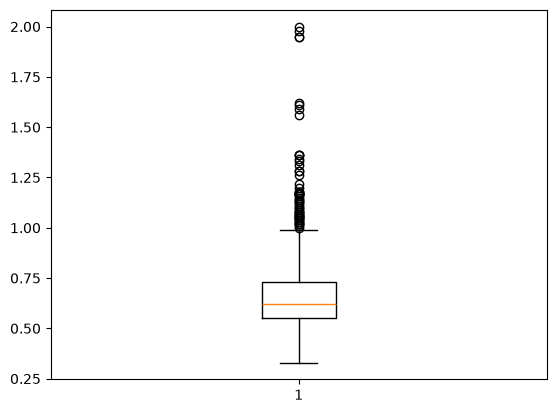

In [10]:
plt.boxplot(df_principal['sulphates'])
plt.show()

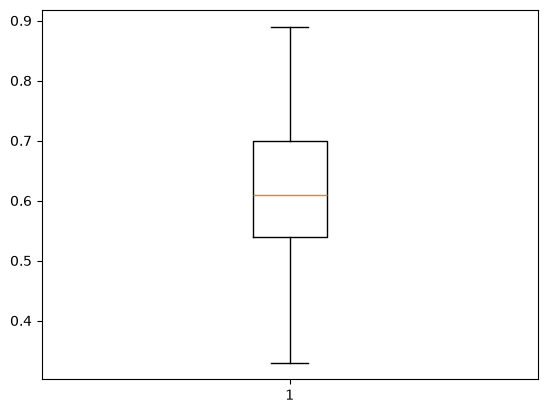

In [11]:
df_principal = df_principal[df_principal['sulphates']<0.9]
plt.boxplot(df_principal['sulphates'])
plt.show()

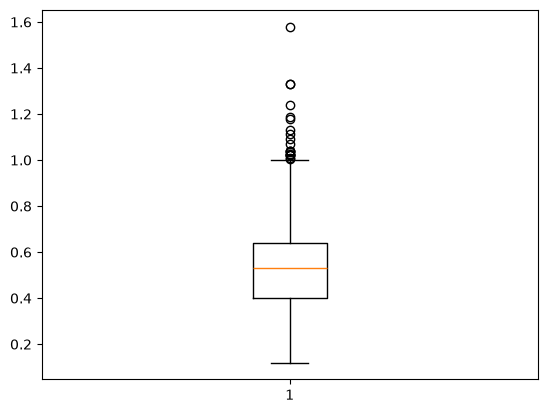

In [12]:
plt.boxplot(df_principal['volatile acidity'])
plt.show()

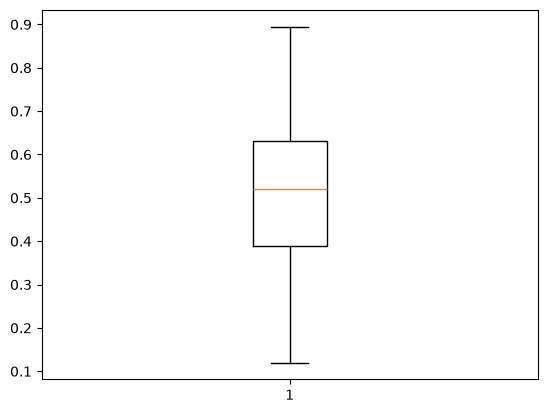

In [13]:
df_principal = df_principal[df_principal['volatile acidity']<0.9]
plt.boxplot(df_principal['volatile acidity'])
plt.show()

# Correlação após filtrar os *outliers*

In [14]:
df_principal.corr()

,alcohol,sulphates,volatile acidity,quality
alcohol,1.000000,0.250721,-0.229816,0.497370
sulphates,0.250721,1.000000,-0.306849,0.401846
volatile acidity,-0.229816,-0.306849,1.000000,-0.354101
quality,0.497370,0.401846,-0.354101,1.000000


Construção do modelo

In [15]:
X = df_principal[['alcohol','sulphates','volatile acidity']]
y = df_principal['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

regressao_linear = LinearRegression()
regressao_linear.fit(X_train, y_train)

coef_table = pd.DataFrame({'variavel': X.columns, 'coeficiente': regressao_linear.coef_}).sort_values(by='coeficiente', ascending = False)
display(coef_table)
print('Intercepto:', regressao_linear.intercept_)

,variavel,coeficiente
1,sulphates,1.692980
0,alcohol,0.309558
2,volatile acidity,-0.933950


Intercepto: 1.84000688646669


Os coeficientes podem ser analisados da seguinte forma:

- Mantendo as demais variáveis **fixas**, um aumento de 1 unidade em `alcohol` está associado a um aumento de 0.30 pontos aproximadamente na `quality`.

# Avaliação do modelo

In [16]:
y_pred = regressao_linear.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'R² (teste): {r2}')
print(f'RMSE: {rmse}')


R² (teste): 0.3777381048138757
RMSE: 0.6022473466624265


Podemos analisar o R² da seguinte forma: quanto mais próximo de 1, melhor o ajuste.

O REQM pode ser interpretado como:

A média de erro de valor é de 0.57 na qualidade.

# Diagnóstico de Resíduos



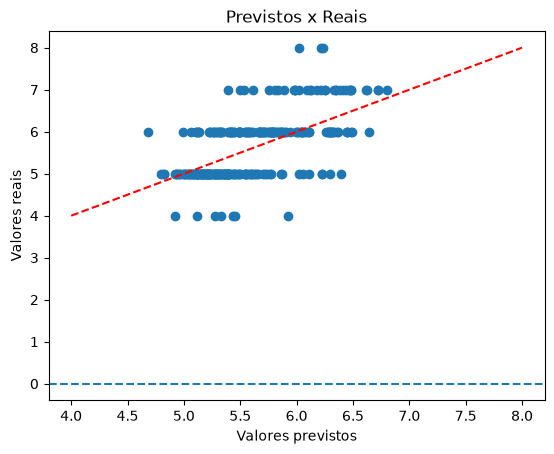

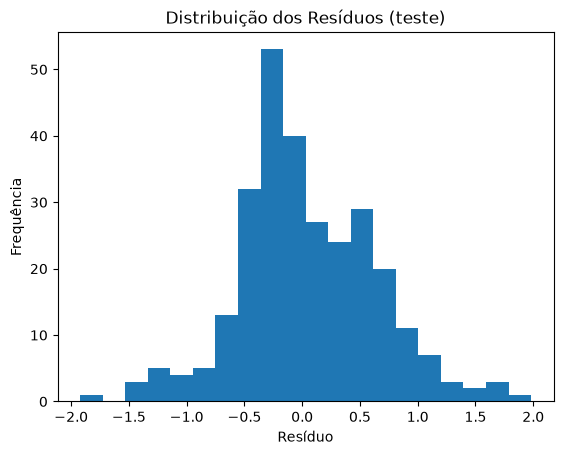

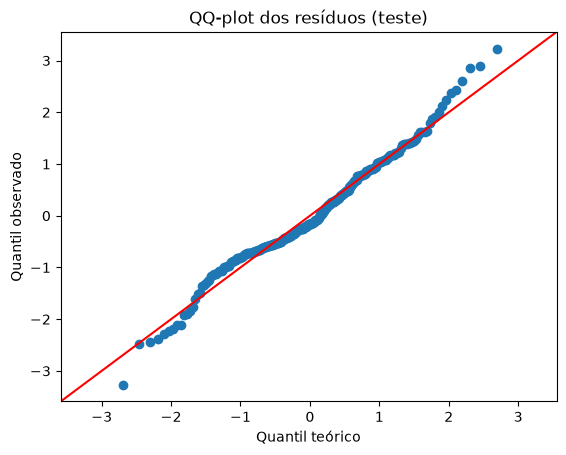

In [17]:

residuos = y_test - y_pred
plt.figure()
plt.scatter(y_pred, y_test)
plt.axhline(0, linestyle='--')
plt.xlabel('Valores previstos')
plt.ylabel('Valores reais')
plt.title('Previstos x Reais')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

plt.figure()
plt.hist(residuos, bins=20)
plt.title('Distribuição dos Resíduos (teste)')
plt.xlabel('Resíduo')
plt.ylabel('Frequência')
plt.show()


from statsmodels.graphics.gofplots import qqplot
grafico_qq = qqplot(y_test - y_pred, line='45', fit=True)
plt.title('QQ-plot dos resíduos (teste)')
plt.xlabel('Quantil teórico')
plt.ylabel('Quantil observado')
plt.show()

# Prevendo valores

In [18]:
independentes = ['alcohol', 'sulphates', 'volatile acidity']


novos = pd.DataFrame({
    'alcohol': [10.40, 11.20],
    'sulphates': [0.50, 0.70],
    'volatile acidity': [0.40, 0.60],
})[independentes]

pred = regressao_linear.predict(novos)
print(pred)


[5.53232001 5.93177231]
